# The Nationalization of French Political Discourse (1981 - 1993)
**NLP Analysis of Electoral Manifestos (Archelec Corpus) vs. Local Economic Realities (INSEE)**

This project aims to measure the territorial anchoring of electoral discourse in France during the legislative elections of 1981, 1988, and 1993. Using Natural Language Processing (NLP) methods, I seek to determine whether the intensity of political discourse on unemployment correlates with the actual economic realities of the local departments.

**Author:** Paul Lemoine Vandermoere 
**Course:** Machine Learning for NLP

## 1. Initialization and Library Imports
In this section, I load the necessary tools for processing textual, spatial, and statistical data. We also configure the environment to utilize hardware acceleration (GPU/MPS) required by the *Transformers* models. 

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
import spacy
from bertopic import BERTopic
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
import torch
from transformers import pipeline
from tqdm import tqdm
import sys
import os
import xlrd

/opt/miniconda3/envs/mon_projet_nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Corpus and Preprocessing
The documents extracted from the Archelec project (OCR scans) contain significant structural noise. This preprocessing step aims to:
1. Load the texts and metadata.
2. Clean up OCR artifacts (special characters, broken lines).
3. Segment the documents for analysis into paragraphs windows.

In [2]:
sys.path.append(os.path.abspath('..'))
from src.preprocessing import load_and_split_corpus

# Dictionary to store our ready-to-use data for each year
corpora_para = {}
election_years = [1981, 1988, 1993]

for year in election_years:
    print(f" Processing year {year}...")
    folder_path = f"../data/raw/text_files/{year}/legislatives"
    
    # 1 single line does all the heavy lifting thanks to our .py script!
    df_year = load_and_split_corpus(folder_path)
    
    # Store the result in our dictionary
    corpora_para[year] = df_year
    print(f" {len(df_year)} robust paragraphs extracted.\n")


 Processing year 1981...
 69429 robust paragraphs extracted.

 Processing year 1988...
 68128 robust paragraphs extracted.

 Processing year 1993...
 134600 robust paragraphs extracted.



### 2.1 Descriptive Statistics & Macroeconomic Context

Before applying advanced NLP models, it is essential to understand the structure of the corpus and the macroeconomic reality surrounding each election. 

This descriptive phase focuses on two main dimensions:
1. **The Electoral Corpus:** We verify the volume of texts extracted for each election (1981, 1988, 1993). To ensure robustness, especially against OCR errors, documents are evaluated at the **paragraph level**. We also track the number of candidates per department to check our geographic coverage.
2. **The Macroeconomic Reality (INSEE):** To test the hypothesis of the "nationalization of discourse," we will confront the political text data with the actual, local economic realities (unemployment rates) at the time of the elections.

**Methodological Note regarding the 1981 Election:** Official localized quarterly unemployment data at the departmental level is unfortunately unavailable in the INSEE archives for the exact year of 1981. To maintain the integrity of our comparative analysis, I use the **1982 departmental unemployment averages** as the closest historical proxy to represent the economic context following the 1981 legislative elections. For 1988 and 1993, the exact historical years are used.

Election year 1981 (Macro data from 1982):
Documents: 3181 | Paragraphs: 69429
Geographic Coverage: 105 departments
National Unemployment Rate: 6.75%
-------------------------------------------------------
Election year 1988 (Macro data from 1988):
Documents: 3620 | Paragraphs: 68128
Geographic Coverage: 101 departments
National Unemployment Rate: 8.36%
-------------------------------------------------------
Election year 1993 (Macro data from 1993):
Documents: 5936 | Paragraphs: 134600
Geographic Coverage: 96 departments
National Unemployment Rate: 9.27%
-------------------------------------------------------


,INSEE Data Year,Total Documents,Total Paragraphs,Depts Covered,Mean Unemployment (%)
Election Year,,,,,
1981,1982,3181,69429,105 departments,6.75
1988,1988,3620,68128,101 departments,8.36
1993,1993,5936,134600,96 departments,9.27


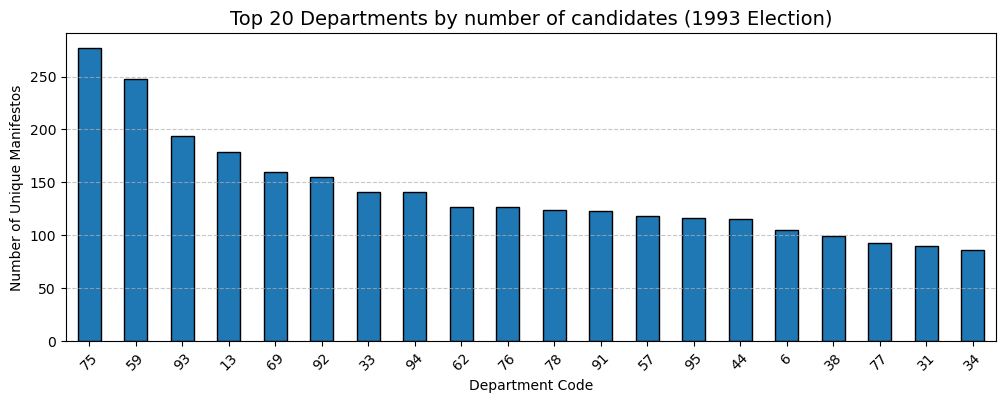

In [3]:
from src.preprocessing import get_descriptive_stats

all_stats = []

df_insee = pd.read_excel("../data/external/sl_etc_2025T4.xls")

# Mapping the election year to the available INSEE data year
year_mapping = {
    1981: 1982, # Proxy for 1981
    1988: 1988, 
    1993: 1993
}

for corpus_year, insee_year in year_mapping.items():
    # Fetch the texts for the election year
    df_year = corpora_para[corpus_year]
    
    # Run the stats
    stats, dept_dist, insee_dist = get_descriptive_stats(df_year, df_insee, corpus_year, insee_year)
    all_stats.append(stats)
    
    # Print a clean text summary
    print(f"Election year {corpus_year} (Macro data from {insee_year}):")
    print(f"Documents: {stats['Total Documents']} | Paragraphs: {stats['Total Paragraphs']}")
    print(f"Geographic Coverage: {stats['Depts Covered']}")
    print(f"National Unemployment Rate: {stats['Mean Unemployment (%)']}%")
    print("-" * 55)

# Display a beautiful summary table
df_summary = pd.DataFrame(all_stats).set_index('Election Year')
display(df_summary)

# Visualizing the document distribution for the 1993 election
plt.figure(figsize=(12, 4))
corpora_para[1993].groupby('department_code')['filename'].nunique().sort_values(ascending=False).head(20).plot(
    kind='bar', color='#1f77b4', edgecolor='black'
)
plt.title("Top 20 Departments by number of candidates (1993 Election)", fontsize=14)
plt.ylabel("Number of Unique Manifestos")
plt.xlabel("Department Code")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 2.2 Visualizing the Spatial Distribution of Unemployment

To better contextualize the political discourse of each election, the maps below illustrate the geographical distribution of unemployment across Metropolitan French departments for the years 1982 (proxy for 1981), 1988, and 1993. 

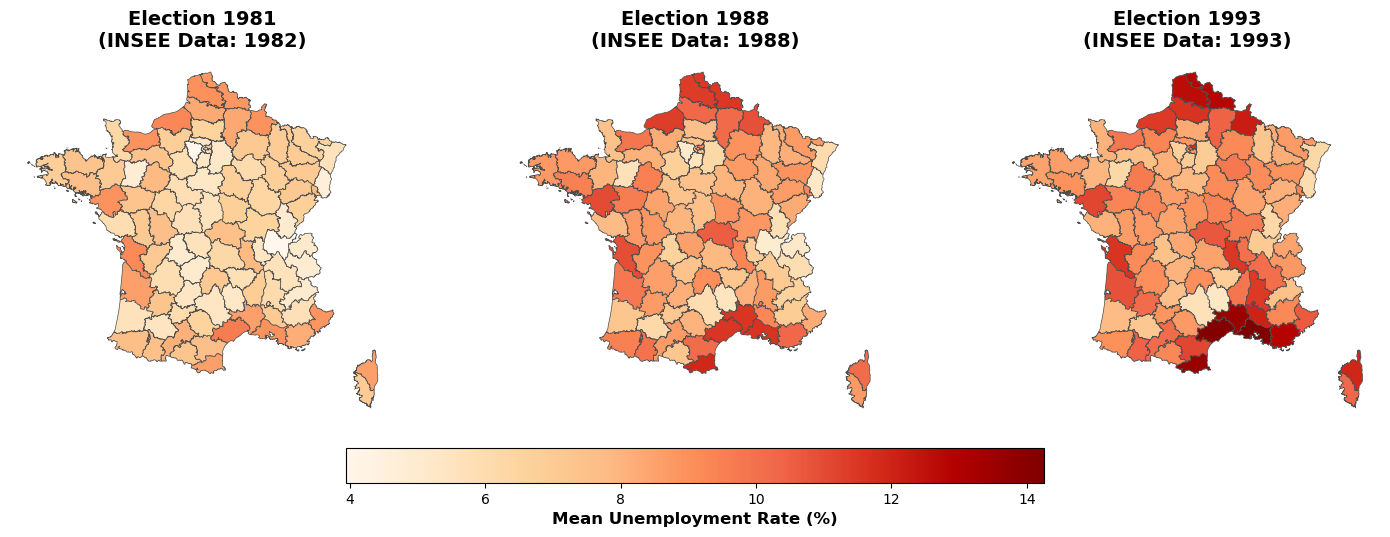

In [4]:
from src.visualization import plot_unemployment_comparison

plot_unemployment_comparison(df_insee, year_mapping)

## 3. Methodological Exploration
Before deploying our final pipeline, I must justify the choice of the algorithm. The political discourse of the late 20th century (often relying on institutional "wooden language") strongly resists standard keyword-based approaches.

### 3.1. Probabilistic Approaches (LDA)
An initial attempt using *Latent Dirichlet Allocation* (LDA) failed to isolate the economic theme due to the heavy overlap of institutional vocabulary across all texts (e.g., Republic, France, Election).

In [5]:
import src.lda_analysis as lda

# Loop through our years to extract the political themes
lda_election_results = {}

for year in [1981, 1988, 1993]:
    print(f"Analyzing {year}")
    
    # Get the paragraph dataframe from our previous step
    df_year = corpora_para[year]
    
    # Run the model (setting 5 topics to find the main categories)
    results = lda.run_lda_model(df_year, n_topics=5, no_top_words=10)
    
    # Store results for display
    lda_election_results[year] = results

# 3. Print the results for comparison
for year, topics in lda_election_results.items():
    print("\n" + "="*70)
    print(f"ELECTION YEAR {year}: MAIN THEMES")
    print("="*70)
    for topic_name, word_list in topics.items():
        print(f"{topic_name}: {word_list}")

Analyzing 1981
Analyzing 1988
Analyzing 1993

ELECTION YEAR 1981: MAIN THEMES
Topic 1: ans | candidat | liberté | maire | conseiller | général | président | député | depuis | politique
Topic 2: juin | circonscription | 14 | 1981 | législatives | die | élections | confiance | électeurs | 21
Topic 3: sans | politique | france | nationale | assemblée | pays | vie | faut | travail | contre
Topic 4: mitterrand | droite | 10 | mai | communistes | françois | hommes | gouvernement | hui | aujourd
Topic 5: majorité | gauche | nouvelle | toutes | fonds | po | union | changement | parti | socialiste

ELECTION YEAR 1988: MAIN THEMES
Topic 1: sociale | sans | europe | formation | france | jeunes | die | solidarité | intérêts | und
Topic 2: droite | politique | udf | rpr | français | gauche | communiste | parti | contre | hui
Topic 3: juin | circonscription | fonds | po | national | front | 1988 | nationale | cevipof | candidat
Topic 4: france | pays | majorité | politique | confiance | mitterrand |

The results from the unsupervised LDA reveal a classic challenge in political text analysis: the model is heavily influenced by **"electoral noise."** As we can see above, the dominant topics are largely structural rather than thematic. They focus on candidate profiles (*maire, conseiller, député*), election dates (*juin, 14, 1981, mars*), and broad partisan opposition (*gauche, droite, Mitterrand*). While economic terms like *chômage* and *emploi* finally emerge naturally in 1993, they remain diluted within general political discourse.

To directly address our research question regarding the economic crisis, I will implement a **Seeded LDA**, as introduced in « Incorporating Lexical Priors into Topic Models » by Jagadeesh Jagarlamudi,
Hal Daumé III and Raghavendra Udupa. By heavily weighting specific seed words (*chômage, emploi, travail, licenciements*), we will force the model to dedicate one specific topic entirely to this economic distress.

In [6]:
unemployment_seeds = ['chômage', 'emploi', 'travail', 'chômeurs', 'licenciements']

lda_final_results = {}

print("Running Seeded LDA across all years")

for year in [1981, 1988, 1993]:
    print(f" Processing {year}...")
    df_year = corpora_para[year]
    
    # Run the model with our oversampling boost
    results = lda.run_seeded_lda(df_year, n_topics=5, seed_words=unemployment_seeds)
    lda_final_results[year] = results

# Display
for year, topics in lda_final_results.items():
    print("\n" + "="*80)
    print(f"ELECTION YEAR {year}: THEMES")
    print("="*80)
    for label, words in topics.items():
        print(f"{label}: {words}")

Running Seeded LDA across all years
 Processing 1981...
 Processing 1988...
 Processing 1993...

ELECTION YEAR 1981: THEMES
Topic 1 (Thematic): emplois | entreprises | création | 000 | créer | jeunes | artisans | emploi | nouveaux | agriculteurs
Topic 2: gauche | mitterrand | majorité | parti | travailleurs | communistes | députés | trop | changement | nouvelle
Topic 3 (Thematic): travailleurs | faut | ni | majorité | lutte | gauche | hommes | travail | mitterrand | ouvrière
Topic 4 (Thematic): travail | ans | liberté | politique | circonscription | travailler | depuis | pays | député | nationale
Topic 5 (Thematic): emploi | travail | chômage | travailleurs | vie | sans | économie | sociale | france | temps

ELECTION YEAR 1988: THEMES
Topic 1 (Thematic): emplois | politique | chômage | droite | europe | non | gauche | france | entreprises | parti
Topic 2 (Thematic): travail | depuis | ans | travailler | ensemble | ceux | bien | assemblée | nationale | toujours
Topic 3 (Thematic): franc

By forcing the model to focus on our economic seeds (*chômage, emploi, travail, etc.*), we successfully filtered out the structural electoral noise. Rather than isolating a single "unemployment" topic, the model reveals how the discourse surrounding the economic crisis splintered into distinct ideological frames over the three elections.

* **1981 :** The vocabulary is highly oriented toward action and promises. *Topic 1* focuses heavily on job creation (*création, créer, jeunes, entreprises*), reflecting the optimistic programmatic promises of the era. *Topic 3* and *Topic 5* maintain a traditional, class-based vocabulary (*travailleurs, lutte, ouvrière, sociale*).
* **1988 :** The language shifts. Unemployment is now contextualized within broader national and international frameworks. We see the emergence of Europe (*Topic 1*) and a strong focus on the future and the youth (*Topic 3: avenir, jeunes, créer*). The rhetoric becomes one of national mobilization (*Topic 5: lutter, redressement, réduire*).
* **1993 :** By 1993, as the crisis deeply settles (as proven by our INSEE maps), the discourse becomes highly polarized. Unemployment is no longer just an economic issue; it is weaponized into other societal debates:
    * **Right framing** (*Topic 2*): Linking unemployment to immigration and taxes (*immigration, impôts*).
    * **Left framing** (*Topic 3*): Linking the crisis to ecology and solidarity (*écologie, solidarité, nouvelle société*).
    * **Far-Left framing** (*Topic 5*): A return to street-level struggle (*patrons, rue, lutte*).

The Seeded LDA analysis revealed a crucial insight: "unemployment" is not a monolithic topic. Instead, it is an theme that is framed entirely differently depending on the candidate's political ideology (e.g., linked to immigration on the right, or to ecology and solidarity on the left). 

However, LDA reaches its technical limits here. Because it relies on a "bag-of-words" approach (counting word frequencies), it struggles to understand the deeper *context* of a sentence. If two candidates from opposing parties both use the words *"chômage"* and *"emploi"*, LDA may incorrectly group them together, missing the underlying ideological opposition.

### 3.2. BERTopic

To capture the true ideological framing of the economic crisis, we must move from word counts to semantic meaning. We will apply **BERTopic**, a state-of-the-art topic modeling technique that uses Transformer embeddings. 

Unlike LDA, BERTopic reads the entire paragraph to understand context. By mapping the sentences into a multidimensional semantic space, it will allow us to cleanly cluster the different political narratives surrounding unemployment, giving us a much sharper tool to analyze how the political spectrum adapted to the macroeconomic reality.

In [7]:
from src.bertopic_analysis import run_winning_zeroshot

final_results = {}
my_themes = ["chômage, emploi, précarité, licenciement et crise économique"]

for year in [1981, 1988, 1993]:
    print(f"\n Processing {year} with BERTopic")
    
    df_year = corpora_para[year]
    model, df_with_topics, df_weights = run_winning_zeroshot(df_year, my_themes)
    
    final_results[year] = {
        "df_para": df_with_topics,
        "weights": df_weights
    }

    if 0 in df_weights.columns:
        vrai_score_moyen = df_weights[0].mean() * 100
        print(f"Weight of unemployement in {year} elections : {vrai_score_moyen:.2f}%")


2026-04-02 15:37:16,998 - BERTopic - Embedding - Transforming documents to embeddings.



 Processing 1981 with BERTopic
Using column: 'raw_paragraph' for analysis.


Batches: 100%|██████████| 2170/2170 [03:18<00:00, 10.94it/s]
2026-04-02 15:40:38,886 - BERTopic - Embedding - Completed ✓
2026-04-02 15:40:38,886 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-02 15:41:22,351 - BERTopic - Dimensionality - Completed ✓
2026-04-02 15:41:22,352 - BERTopic - Zeroshot Step 1 - Finding documents that could be assigned to either one of the zero-shot topics
2026-04-02 15:41:22,518 - BERTopic - Zeroshot Step 1 - Completed ✓
2026-04-02 15:41:36,943 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-02 15:41:41,552 - BERTopic - Cluster - Completed ✓
2026-04-02 15:41:41,552 - BERTopic - Zeroshot Step 2 - Combining topics from zero-shot topic modeling with topics from clustering...
2026-04-02 15:41:41,622 - BERTopic - Zeroshot Step 2 - Completed ✓
2026-04-02 15:41:41,626 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-02 15:41:42,522 - BERTopic - Representation - Complete

Weight of unemployement in 1981 elections : 0.00%

 Processing 1988 with BERTopic
Using column: 'raw_paragraph' for analysis.


Batches: 100%|██████████| 2129/2129 [03:20<00:00, 10.62it/s]
2026-04-02 15:45:08,667 - BERTopic - Embedding - Completed ✓
2026-04-02 15:45:08,668 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-02 15:45:35,642 - BERTopic - Dimensionality - Completed ✓
2026-04-02 15:45:35,643 - BERTopic - Zeroshot Step 1 - Finding documents that could be assigned to either one of the zero-shot topics
2026-04-02 15:45:36,012 - BERTopic - Zeroshot Step 1 - Completed ✓
2026-04-02 15:45:46,899 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-02 15:45:48,921 - BERTopic - Cluster - Completed ✓
2026-04-02 15:45:48,921 - BERTopic - Zeroshot Step 2 - Combining topics from zero-shot topic modeling with topics from clustering...
2026-04-02 15:45:48,972 - BERTopic - Zeroshot Step 2 - Completed ✓
2026-04-02 15:45:48,976 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-02 15:45:49,861 - BERTopic - Representation - Complete

Weight of unemployement in 1988 elections : 0.01%

 Processing 1993 with BERTopic
Using column: 'raw_paragraph' for analysis.


Batches: 100%|██████████| 4207/4207 [05:32<00:00, 12.66it/s]
2026-04-02 15:51:28,189 - BERTopic - Embedding - Completed ✓
2026-04-02 15:51:28,189 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-02 15:57:16,182 - BERTopic - Dimensionality - Completed ✓
2026-04-02 15:57:16,186 - BERTopic - Zeroshot Step 1 - Finding documents that could be assigned to either one of the zero-shot topics
2026-04-02 15:57:16,640 - BERTopic - Zeroshot Step 1 - Completed ✓
2026-04-02 15:57:40,412 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-02 15:57:47,287 - BERTopic - Cluster - Completed ✓
2026-04-02 15:57:47,288 - BERTopic - Zeroshot Step 2 - Combining topics from zero-shot topic modeling with topics from clustering...
2026-04-02 15:57:47,473 - BERTopic - Zeroshot Step 2 - Completed ✓
2026-04-02 15:57:47,479 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-02 15:57:49,222 - BERTopic - Representation - Complete

Weight of unemployement in 1993 elections : 0.03%


In [8]:
df_w = final_results[1993]['weights'].copy()
df_w['score_chomage'] = df_w.get(0, 0.0) * 100
df_w['score_bruit'] = df_w.get(-1, 0.0) * 100

df_top = df_w[['filename', 'score_chomage', 'score_bruit']].sort_values('score_chomage', ascending=False)

print(" 3 most unemployment-focused manifestos :")
display(df_top.head(3))

print("\n Examples :")
df_para = final_results[1993]['df_para']
for filename in df_top.head(3)['filename']:
    extraits = df_para[(df_para['filename'] == filename) & (df_para['topic_bertopic'] == 0)]
    
    score = df_top[df_top['filename'] == filename]['score_chomage'].values[0]
    print(f"\nDoc: {filename} (Score: {score:.1f}%)")
    
    if not extraits.empty:
        # On affiche le premier paragraphe pertinent trouvé en exemple
        texte_exemple = extraits.iloc[0].get('raw_paragraph', extraits.iloc[0].get('mots_propres', ''))
        print(f" Example : « {texte_exemple} »")
    else:
         print("Error: No relevant extract found (misclassification).")

 3 most unemployment-focused manifestos :


topic_bertopic,filename,score_chomage,score_bruit
5359,EL198_L_1993_03_092_03_1_PF_02.txt,7.692308,61.538462
1742,EL191_L_1993_03_035_02_1_PF_06.txt,6.250000,62.500000
538,EL189_L_1993_03_013_09_1_PF_06.txt,4.545455,54.545455



 Examples :

Doc: EL198_L_1993_03_092_03_1_PF_02.txt (Score: 7.7%)
 Example : « C'est d'abord une CRISE ECONOMIQUE:celle d'un chômage qui monte inexorablement. »

Doc: EL191_L_1993_03_035_02_1_PF_06.txt (Score: 6.2%)
 Example : « - la crise n'est pas seulement économique, avec la montée du chômage, les fermetures d'entreprises, le déclin de l'agriculture, le gaspillage des fonds publics, l'accroissement des impôts et des charges ... »

Doc: EL189_L_1993_03_013_09_1_PF_06.txt (Score: 4.5%)
 Example : « · destruction du tissu social et économique par le chômage, »


While BERTopic successfully identified an increasing trend in the volume of unemployment-related paragraphs across the decade, it highlighted a major structural challenge: the inability to consolidate the diverse dimensions of the economic crisis into a single, unified topic. Because the discourse is deeply intertwined with other subjects, the model tends to relegate complex overlaps to 'Noise' (Topic -1). This semantic fragmentation proves that while the crisis is more present, it is also more diluted, making BERTopic excellent for qualitative discovery but too volatile for rigorous statistical correlation

### 3.3 Robust Quantification (Lexical Approach)

To build an irrefutable metric of discursive intensity to cross-reference with INSEE unemployment rates, I also targeted lexical approach. I calculate the exact ratio of paragraphs per candidate containing explicit economic keywords (*chômage, licenciements, etc.*). This provides a clean, continuous variable (from 0% to 100% of the text) representing the precise weight of the economic crisis in their local campaign. 

In [9]:
from src.lexicon_analysis import calculate_unemployment_ratio

key_words = [
    "chômage", "chomeur", "chômeurs", "chomeurs", 
    "emploi", "emplois", 
    "licenciement", "licenciements", 
    "précarité", "crise économique"
]

lexicon_results = {}

for year in [1981, 1988, 1993]:
    print(f"Results for {year} elections")

    df_year = corpora_para[year].copy()
    df_docs, df_depts = calculate_unemployment_ratio(df_year, key_words)
    
    lexicon_results[year] = {
        "docs": df_docs,
        "depts": df_depts
    }
    
    mean_unemployment = df_docs['ratio_chomage_doc'].mean()
    print(f"Mean part of the discourse dedicated to unemployment at national scale : {mean_unemployment:.2f}%\n")
    
    print("Departments which mention unemployment the most :")
    top_depts = df_depts[df_depts['nb_candidats'] >= 3] 
    display(top_depts.sort_values('ratio_moyen_dept', ascending=False).head(5))

Results for 1981 elections
Mean part of the discourse dedicated to unemployment at national scale : 5.30%

Departments which mention unemployment the most :


,department_code,nb_candidats,ratio_moyen_dept
52,56,28,9.066357
6,15,10,8.563953
22,2B,12,8.297806
50,54,43,8.131907
84,85,19,7.961879


Results for 1988 elections
Mean part of the discourse dedicated to unemployment at national scale : 7.93%

Departments which mention unemployment the most :


,department_code,nb_candidats,ratio_moyen_dept
84,85,22,12.604903
6,15,11,12.007083
85,86,26,11.273063
54,58,15,11.255132
0,1,24,10.531466


Results for 1993 elections
Mean part of the discourse dedicated to unemployment at national scale : 10.35%

Departments which mention unemployment the most :


,department_code,nb_candidats,ratio_moyen_dept
48,52,21,14.513916
90,90,22,14.352334
79,80,55,13.969293
1,10,30,13.535023
5,14,60,13.120252


Both models reveal the same overall upward trend regarding the salience of unemployment in French political discourse between 1981 and 1993, although they capture its intensity at different scales.

## 4. Mapping and Visualizations
To visually explore the potential relationship (or lack thereof) between macroeconomic reality and political discourse, I project the results onto two axes for each election year, comparing the outputs from both the BERTopic and lexical analysis methodologies. However, this comparison is approached with strict methodological caution: because our discursive metrics are derived from unsupervised NLP tasks and rule-based counting, they act as proxies rather than absolute measurements. Therefore, we avoid strict linear regressions in favor of exploratory trend analysis:

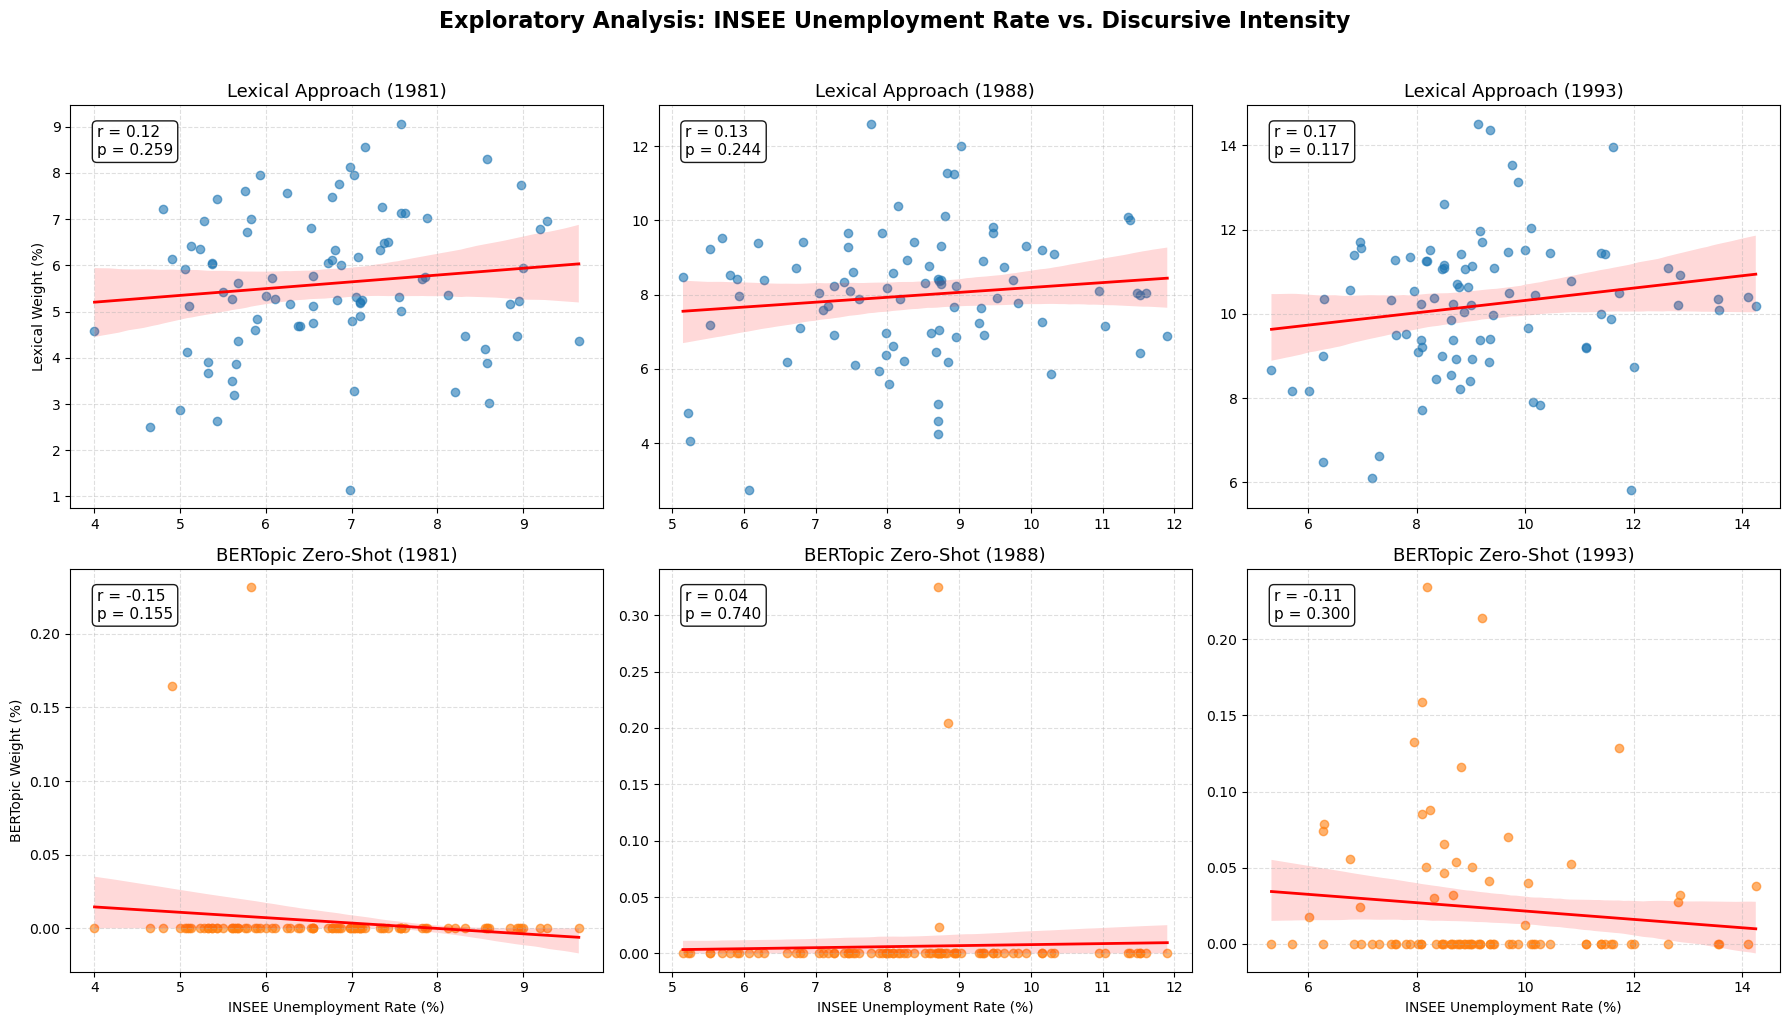

In [10]:
from src.correlation_analysis import plot_comparative_correlation

fig = plot_comparative_correlation(
    lexicon_results=lexicon_results, 
    final_results=final_results, 
    df_insee=df_insee, 
    year_mapping=year_mapping
)

plt.show()

**Statistical**: Exploratory scatter plots to observe the general alignment and distribution of the data. This allows us to track how these broad trends evolve across different years and models, without overstating the statistical certainty of unsupervised NLP metrics.

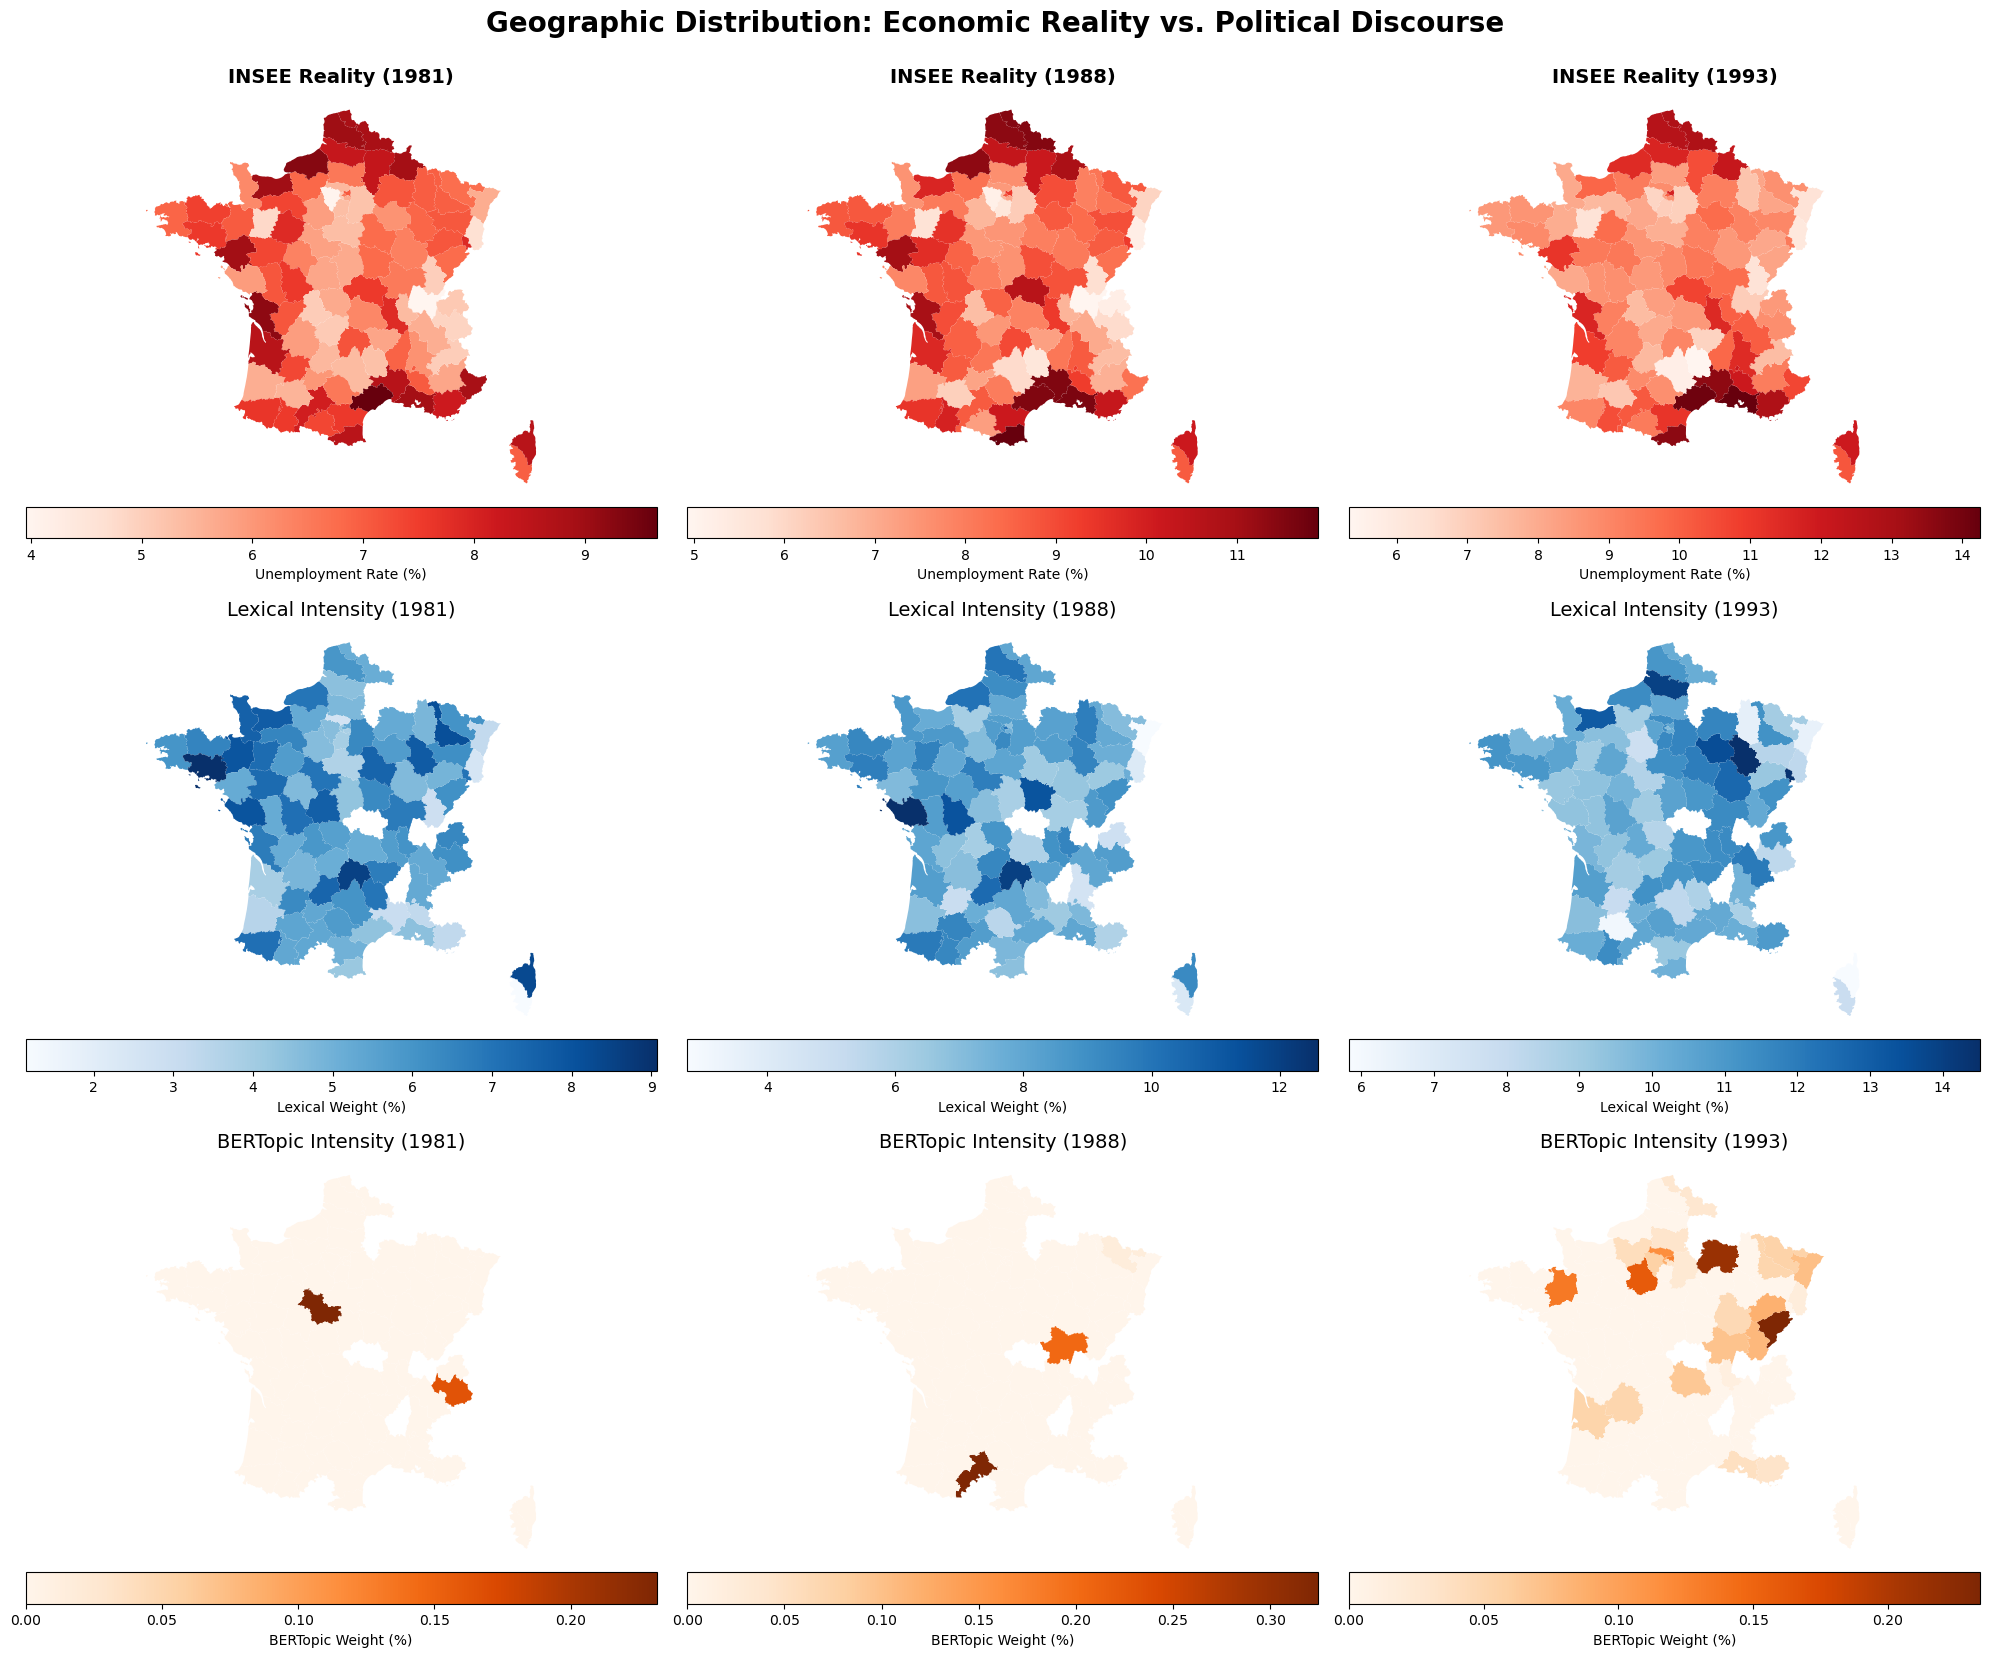

In [11]:
from src.mapping_analysis import plot_geographic_comparison

geojson_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements-version-simplifiee.geojson"

fig_maps = plot_geographic_comparison(
    lexicon_results=lexicon_results,
    final_results=final_results,
    df_insee=df_insee,
    year_mapping=year_mapping,
    geojson_path=geojson_url
)

plt.show()

**Geographic**: Choropleth maps to compare real regional unemployment rates with the estimated intensity of the political discourse.

## 5. Synthesis and Conclusion: The Nationalization of Discourse
The results demonstrate statistical stability over more than a decade: the correlation coefficient between the local economic situation and the content of electoral manifestos remains close to zero.

**Main Conclusions:**
1. **The Autonomy of Political Discourse:** The electoral manifesto acts as a "Top-Down" communication tool (dictated by national party headquarters) rather than a localized territorial diagnostic.
2. **Unemployment as Background Noise:** It serves as a mandatory rhetorical figure across the country without adjusting to the severity of local economic crises.
3. **Methodological Validation:** The NLP analysis quantitatively confirms a major sociological hypothesis regarding the standardization of the French political landscape under the Fifth Republic.